Importing necessary libraries for data analysis, visualization, and database connection. Enabling inline plotting for charts.

Импорт базовых библиотек для анализа, визуализации данных и работы с СУБД. Включение интерактивного режима отображения графиков.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from itertools import product
import kagglehub as kh
from os import environ
from getpass import getpass
%matplotlib inline

Downloading data from KaggleHub and setting up a secure connection to a PostgreSQL database via create_engine.

Загрузка датасета через API KaggleHub и инициализация защищенного SSL-соединения с базой данных PostgreSQL.

In [2]:
environ["KAGGLEHUB_ANONYMOUS_DOWNLOAD"]='1'
filepath=kh.dataset_download("geethasagarbonthu/marketing-and-e-commerce-analytics-dataset")
db_user=input("Username: ")
db_password=getpass("Password: ")
db_host=input("Host: ")
db_port=input("Port: ")
db_name=input("Database name: ")
engine=create_engine(f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}", connect_args={"sslmode": "require"})

Using Colab cache for faster access to the 'marketing-and-e-commerce-analytics-dataset' dataset.


Loading data from four CSV files (campaigns, customers, products, transactions) into Pandas DataFrames using UTF-8 encoding.

Чтение данных из четырех CSV-файлов (campaigns, customers, products, transactions) в объекты DataFrame с явным указанием кодировки UTF-8.

In [3]:
df1=pd.read_csv(f'{filepath}/campaigns.csv', encoding='utf-8')
df2=pd.read_csv(f'{filepath}/customers.csv', encoding='utf-8')
df3=pd.read_csv(f'{filepath}/products.csv', encoding='utf-8')
df4=pd.read_csv(f'{filepath}/transactions.csv', encoding='utf-8')

Reading a large event file (events.csv) in chunks of 100,000 rows and writing it to the SQL database table (ecommerce_events). This process takes approximately 1.5 to 2 minutes.

Потоковое чтение большого файла событий (events.csv) частями по 100 000 строк и запись пакетов в таблицу СУБД (ecommerce_events). Расчетное время выполнения операции составляет 1.5–2 минуты.

In [4]:
for n, i in enumerate(pd.read_csv(f'{filepath}/events.csv', chunksize=100000, low_memory=False)):
    mode="replace" if n==0 else "append"
    i.to_sql(name='ecommerce_events', con=engine, if_exists=mode, index=False)

Configuring the default font family for Matplotlib and creating a helper function to automatically add text labels on top of bar charts.

Глобальная настройка шрифтов для графической библиотеки и создание вспомогательной функции для автоматического добавления числовых меток над элементами гистограмм.

In [5]:
plt.rcParams['font.family'] = 'DejaVu Sans'
def func1(ax):
    for container in ax.containers:
        ax.bar_label(container, padding=2)

Checking the structure, data types, dimensions, and the first 20 rows of the marketing campaigns dataset.

Вывод технической информации о структуре, типах данных, размерности матрицы и первых двадцати строках таблицы маркетинговых кампаний.

In [6]:
df1.info(memory_usage='deep')
print(df1.shape)
display(df1.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   campaign_id      50 non-null     int64  
 1   channel          50 non-null     object 
 2   objective        50 non-null     object 
 3   start_date       50 non-null     object 
 4   end_date         50 non-null     object 
 5   target_segment   50 non-null     object 
 6   expected_uplift  50 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 15.2 KB
(50, 7)


,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift
0,1,Paid Search,Cross-sell,2021-10-25,2021-11-26,Deal Seekers,0.022
1,2,Email,Retention,2021-10-24,2021-12-24,Deal Seekers,0.116
2,3,Email,Reactivation,2023-10-08,2023-11-30,Churn Risk,0.100
3,4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.111
4,5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.144
5,6,Affiliate,Reactivation,2021-10-20,2021-12-03,New Customers,0.087
6,7,Paid Search,Cross-sell,2023-07-02,2023-08-10,High Value,0.136
7,8,Paid Search,Cross-sell,2021-08-23,2021-09-30,Churn Risk,0.128
8,9,Social,Retention,2023-10-09,2023-12-30,All,0.113
9,10,Email,Cross-sell,2022-09-01,2022-10-22,Churn Risk,0.034


Converting identifiers to integer types and strings to datetime objects. Checking for duplicate rows, unique values, and categorical values in the campaigns table.

Приведение идентификаторов к целочисленному формату, конвертация строковых дат в формат datetime. Проверка на наличие дубликатов и аудит уникальных значений категориальных признаков.

In [7]:
df1['campaign_id']=df1['campaign_id'].astype('int32')
df1['start_date']=pd.to_datetime(df1['start_date'])
df1['end_date']=pd.to_datetime(df1['end_date'])
print(df1.duplicated().sum())
print(df1['campaign_id'].duplicated().sum())
print(df1['channel'].unique().tolist())
print(df1['objective'].unique().tolist())
print(df1['target_segment'].unique().tolist())

0
0
['Paid Search', 'Email', 'Display', 'Social', 'Affiliate']
['Cross-sell', 'Retention', 'Reactivation', 'Acquisition']
['Deal Seekers', 'Churn Risk', 'New Customers', 'High Value', 'All']


Displaying internal DataFrame information, basic descriptive statistics for numeric columns, and printing the top rows of the campaigns table.

Повторный вызов системной информации, расчет ключевых метрик описательной статистики для числовых бизнес-метрик и контрольный вывод строк.

In [8]:
df1.info(memory_usage='deep')
display(df1.describe())
display(df1.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   campaign_id      50 non-null     int32         
 1   channel          50 non-null     object        
 2   objective        50 non-null     object        
 3   start_date       50 non-null     datetime64[ns]
 4   end_date         50 non-null     datetime64[ns]
 5   target_segment   50 non-null     object        
 6   expected_uplift  50 non-null     float64       
dtypes: datetime64[ns](2), float64(1), int32(1), object(3)
memory usage: 10.1 KB


,campaign_id,start_date,end_date,expected_uplift
count,50.00000,50,50,50.000000
mean,25.50000,2022-07-04 18:43:12,2022-08-24 18:14:24,0.086660
min,1.00000,2021-01-20 00:00:00,2021-02-21 00:00:00,0.022000
25%,13.25000,2021-11-12 06:00:00,2022-01-11 18:00:00,0.057250
50%,25.50000,2022-07-17 00:00:00,2022-09-23 12:00:00,0.092500
75%,37.75000,2023-03-17 06:00:00,2023-04-17 18:00:00,0.113750
max,50.00000,2023-11-04 00:00:00,2024-01-06 00:00:00,0.144000
std,14.57738,NaN,NaN,0.035854


,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift
0,1,Paid Search,Cross-sell,2021-10-25,2021-11-26,Deal Seekers,0.022
1,2,Email,Retention,2021-10-24,2021-12-24,Deal Seekers,0.116
2,3,Email,Reactivation,2023-10-08,2023-11-30,Churn Risk,0.100
3,4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.111
4,5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.144
5,6,Affiliate,Reactivation,2021-10-20,2021-12-03,New Customers,0.087
6,7,Paid Search,Cross-sell,2023-07-02,2023-08-10,High Value,0.136
7,8,Paid Search,Cross-sell,2021-08-23,2021-09-30,Churn Risk,0.128
8,9,Social,Retention,2023-10-09,2023-12-30,All,0.113
9,10,Email,Cross-sell,2022-09-01,2022-10-22,Churn Risk,0.034


Creating a copy of the campaign data, calculating the duration of each marketing campaign in days, and sorting the results to see the longest ones.

Дублирование структуры данных, вычисление продолжительности маркетинговых активностей в днях, сортировка по убыванию и вывод топ-20 длительных кампаний.

In [9]:
group_df1=df1.copy()
group_df1['days']=(group_df1['end_date']-group_df1['start_date']).dt.days
display(group_df1.sort_values(by='days', ascending=False).head(20))

,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift,days
47,48,Paid Search,Acquisition,2022-01-05,2022-04-04,New Customers,0.099,89
22,23,Paid Search,Retention,2022-10-25,2023-01-19,Deal Seekers,0.107,86
12,13,Display,Reactivation,2022-03-19,2022-06-09,Churn Risk,0.063,82
4,5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.144,82
8,9,Social,Retention,2023-10-09,2023-12-30,All,0.113,82
25,26,Email,Reactivation,2023-08-13,2023-11-01,Deal Seekers,0.037,80
21,22,Affiliate,Reactivation,2022-07-02,2022-09-18,High Value,0.038,78
43,44,Affiliate,Reactivation,2021-01-31,2021-04-17,All,0.141,76
3,4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.111,74
10,11,Affiliate,Reactivation,2022-11-02,2023-01-14,Churn Risk,0.104,73


Grouping the data and creating three bar plots to analyze the average campaign duration by channels, objectives, and target segments

Группировка данных и построение мультиграфика из трех столбчатых диаграмм для сравнительного анализа средней продолжительности кампаний в разрезе каналов, целей и целевых сегментов.

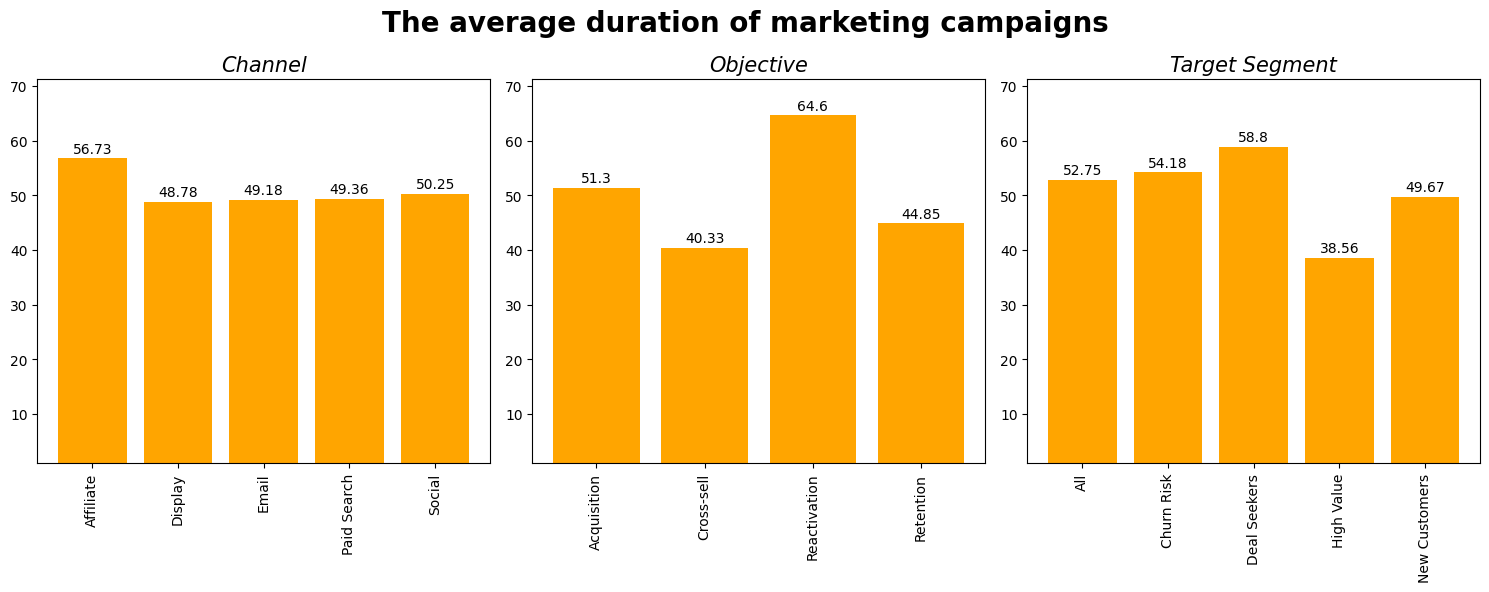

In [10]:
fig, axes=plt.subplots(1, 3, figsize=(15, 6))
for n, row in enumerate(['channel', 'objective', 'target_segment']):
    bar_value=group_df1.groupby(row, as_index=False)['days'].agg(lambda x: np.round(x.mean(), 2))
    axes[n].bar(bar_value[row], bar_value['days'], color='orange')
    for i in axes[n].containers:
        axes[n].bar_label(i, padding=2)
    axes[n].set_ylim(1, group_df1['days'].max()*0.8)
    axes[n].tick_params(axis='x', rotation=90)
    axes[n].set_title(row.replace('_', ' ').title(), style='italic', fontsize=15)
plt.suptitle('The average duration of marketing campaigns', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

Grouping the dataset by target segments and calculating the minimum, maximum, and average values for expected uplift.

Группировка данных по целевой аудитории с расчетом минимального, максимального и среднего прогнозного прироста (uplift).

In [11]:
display(df1.groupby('target_segment', as_index=False)['expected_uplift'].agg(['min', 'mean', 'max']))

,target_segment,min,mean,max
0,All,0.030,0.095500,0.141
1,Churn Risk,0.023,0.071000,0.128
2,Deal Seekers,0.022,0.086400,0.128
3,High Value,0.038,0.088444,0.140
4,New Customers,0.057,0.094000,0.144


Grouping data by marketing channels and creating a horizontal bar plot to show the total expected efficiency for each channel.

Расчет совокупной прогнозной эффективности по маркетинговым каналам и построение горизонтальной столбчатой диаграммы.

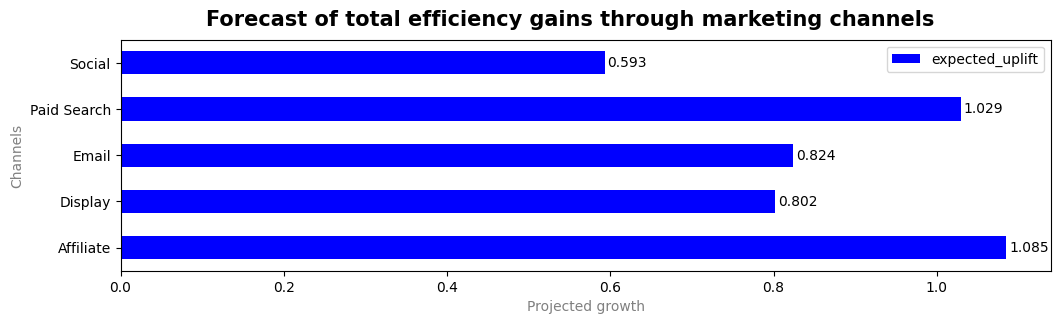

In [12]:
bar_df1=df1.groupby('channel', as_index=False)['expected_uplift'].sum()
ax_bar=bar_df1.plot(kind='barh', x='channel', y='expected_uplift', color='blue', figsize=(12, 3))
plt.xlabel('Projected growth', fontsize=10, color='grey')
plt.ylabel('Channels', fontsize=10, color='grey')
func1(ax_bar)
plt.suptitle('Forecast of total efficiency gains through marketing channels', fontsize=15, fontweight='bold')
plt.show()

Displaying technical metadata, total rows and columns, and the initial records of the customer dataset.

Вывод технической спецификации, общей размерности и первых двадцати строк таблицы профилей клиентов.

In [13]:
df2.info(memory_usage='deep')
print(df2.shape)
display(df2.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          100000 non-null  int64 
 1   signup_date          100000 non-null  object
 2   country              100000 non-null  object
 3   age                  100000 non-null  int64 
 4   gender               100000 non-null  object
 5   loyalty_tier         100000 non-null  object
 6   acquisition_channel  100000 non-null  object
dtypes: int64(2), object(5)
memory usage: 27.8 MB
(100000, 7)


,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1,2021-04-08,BR,48,Male,Bronze,Referral
1,2,2023-04-28,IN,36,Female,Silver,Organic
2,3,2022-12-18,UK,35,Female,Silver,Organic
3,4,2022-04-26,US,45,Male,Silver,Paid Search
4,5,2022-04-20,IN,53,Male,Silver,Organic
5,6,2023-07-30,IN,31,Female,Bronze,Paid Search
6,7,2021-04-05,IN,35,Female,Silver,Social
7,8,2023-02-03,US,36,Male,Bronze,Organic
8,9,2021-08-09,BR,33,Female,Bronze,Paid Search
9,10,2021-04-14,US,36,Male,Bronze,Email


Checking for duplicates, verifying that user IDs are unique, and listing all unique values for countries, genders, loyalty tiers, and acquisition channels.

Проверка таблицы клиентов на полные дубликаты, валидация уникальности первичного ключа (customer_id) и вывод списков уникальных значений для категориальных полей.

In [14]:
print(df2.duplicated().sum())
print(df2['customer_id'].duplicated().sum())
print(df2['country'].unique().tolist())
print(df2['gender'].unique().tolist())
print(df2['loyalty_tier'].unique().tolist())
print(df2['acquisition_channel'].unique().tolist())

0
0
['BR', 'IN', 'UK', 'US', 'CA', 'AU', 'DE']
['Male', 'Female', 'Other']
['Bronze', 'Silver', 'Gold', 'Platinum']
['Referral', 'Organic', 'Paid Search', 'Social', 'Email']


Grouping customer counts by gender and country, calculating totals, and displaying the combined results in a structured format.

Многомерная группировка объема клиентской базы по полу и странам с последующим расчетом итоговых сумм и сортировкой.

In [15]:
grouping1=df2.groupby(['gender', 'country'], as_index=False)['customer_id'].count()
grouping1['marker']=0
grouping2=df2.groupby('gender', as_index=False)['customer_id'].count()
grouping2['marker']=1
grouping2['country']='Result'
display(pd.concat([grouping1, grouping2]).sort_values(by=['gender', 'marker']).drop(columns=['marker']))

,gender,country,customer_id
0,Female,AU,3294
1,Female,BR,4859
2,Female,CA,4737
3,Female,DE,3759
4,Female,IN,9680
5,Female,UK,4828
6,Female,US,16849
0,Female,Result,48006
7,Male,AU,3436
8,Male,BR,4773


Filtering out non-binary genders, optimizing integer data types for memory, converting strings to dates, and replacing short country codes with full names.

Фильтрация аномальных значений пола, оптимизация типов данных для снижения нагрузки на память, конвертация дат и маппинг двухбуквенных кодов стран в полные наименования.

In [16]:
df2=df2[df2['gender']!='Other']
df2[['customer_id', 'age']]=df2[['customer_id', 'age']].astype('int32')
df2['signup_date']=pd.to_datetime(df2['signup_date'])
countries_list={
    'BR': 'Brazil',
    'IN': 'India',
    'UK': 'United Kingdom',
    'US': 'USA',
    'CA': 'Canada',
    'AU': 'Australia',
    'DE': 'Germany'
}
df2['country']=df2['country'].map(countries_list)
df2.info(memory_usage='deep')
display(df2.describe())
display(df2.head(20))

<class 'pandas.core.frame.DataFrame'>
Index: 96060 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          96060 non-null  int32         
 1   signup_date          96060 non-null  datetime64[ns]
 2   country              96060 non-null  object        
 3   age                  96060 non-null  int32         
 4   gender               96060 non-null  object        
 5   loyalty_tier         96060 non-null  object        
 6   acquisition_channel  96060 non-null  object        
dtypes: datetime64[ns](1), int32(2), object(4)
memory usage: 22.4 MB


,customer_id,signup_date,age
count,96060.000000,96060,96060.000000
mean,49974.049323,2022-07-02 12:12:42.723298048,35.222736
min,1.000000,2021-01-01 00:00:00,18.000000
25%,24981.750000,2021-10-02 00:00:00,28.000000
50%,49946.500000,2022-07-03 12:00:00,35.000000
75%,74954.250000,2023-04-02 00:00:00,42.000000
max,100000.000000,2023-12-31 00:00:00,70.000000
std,28860.170055,NaN,9.593568


,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1,2021-04-08,Brazil,48,Male,Bronze,Referral
1,2,2023-04-28,India,36,Female,Silver,Organic
2,3,2022-12-18,United Kingdom,35,Female,Silver,Organic
3,4,2022-04-26,USA,45,Male,Silver,Paid Search
4,5,2022-04-20,India,53,Male,Silver,Organic
5,6,2023-07-30,India,31,Female,Bronze,Paid Search
6,7,2021-04-05,India,35,Female,Silver,Social
7,8,2023-02-03,USA,36,Male,Bronze,Organic
8,9,2021-08-09,Brazil,33,Female,Bronze,Paid Search
9,10,2021-04-14,USA,36,Male,Bronze,Email


Creating a new categorical column to classify customers into 'Young', 'Middle', or 'Older' cohorts based on their age values.

Сегментация непрерывной переменной возраста на фиксированные интервалы (дискретизация) с присвоением текстовых категорий (Young, Middle, Older).

In [17]:
group_df2=df2.copy()
conditions=[
    df2['age'].between(18, 35),
    df2['age'].between(36, 59)]
results=['Young', 'Middle']
group_df2['age_status']=np.select(conditions, results, 'Older')
display(group_df2.head(20))

,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel,age_status
0,1,2021-04-08,Brazil,48,Male,Bronze,Referral,Middle
1,2,2023-04-28,India,36,Female,Silver,Organic,Middle
2,3,2022-12-18,United Kingdom,35,Female,Silver,Organic,Young
3,4,2022-04-26,USA,45,Male,Silver,Paid Search,Middle
4,5,2022-04-20,India,53,Male,Silver,Organic,Middle
5,6,2023-07-30,India,31,Female,Bronze,Paid Search,Young
6,7,2021-04-05,India,35,Female,Silver,Social,Young
7,8,2023-02-03,USA,36,Male,Bronze,Organic,Middle
8,9,2021-08-09,Brazil,33,Female,Bronze,Paid Search,Young
9,10,2021-04-14,USA,36,Male,Bronze,Email,Middle


Generating a 2x2 grid of pie charts to visualize the percentage distribution of customers by country, age group, gender, and loyalty tier.

Построение матрицы круговых диаграмм размера 2x2 для анализа долей клиентов по географии, возрастным группам, гендеру и уровням лояльности.

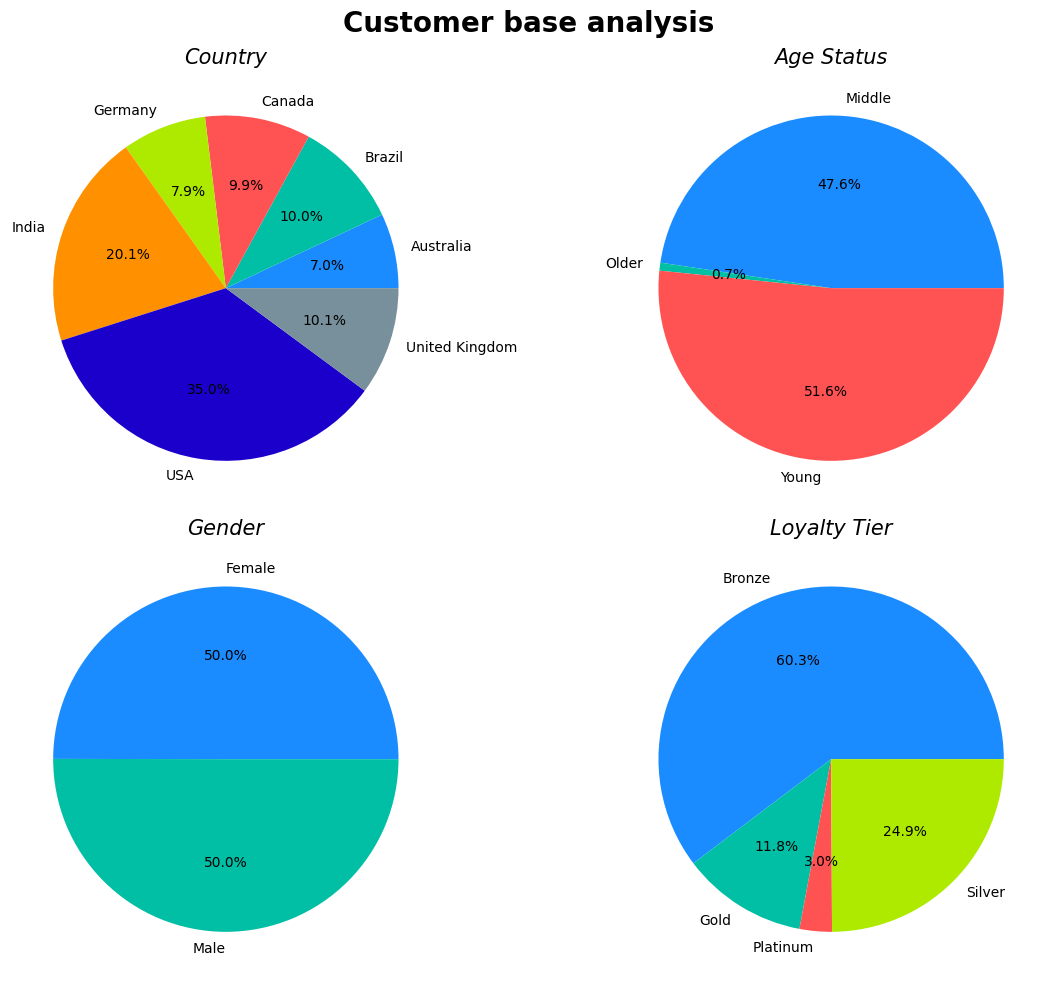

In [18]:
my_colors_pack=['#1a8cff', '#00bfa5', '#ff5252', '#aeea00', '#ff9100', "#1b00cb", '#78909c']
fig, axes=plt.subplots(2, 2, figsize=(12, 10))
lst=['country', 'age_status', 'gender', 'loyalty_tier']
for idx, row in zip(product([0, 1], range(2)), lst):
    df2_pie=group_df2.groupby(row, as_index=False)['customer_id'].count()
    axes[idx[0], idx[1]].pie(df2_pie['customer_id'], labels=df2_pie[row], colors=my_colors_pack, autopct='%1.1f%%')
    axes[idx[0], idx[1]].set_title(row.replace('_', ' ').title(), fontsize=15, style='italic')
plt.suptitle('Customer base analysis', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

Checking the memory usage, data types, dimensions, and the initial rows of the product catalog dataset.

Оценка занимаемой памяти, вывод типов данных, общего количества номенклатуры и первых записей каталога товаров.

In [19]:
df3.info(memory_usage='deep')
print(df3.shape)
display(df3.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   2000 non-null   int64  
 1   category     2000 non-null   object 
 2   brand        2000 non-null   object 
 3   base_price   2000 non-null   float64
 4   launch_date  2000 non-null   object 
 5   is_premium   2000 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 383.0 KB
(2000, 6)


,product_id,category,brand,base_price,launch_date,is_premium
0,1,Grocery,Brand_58,14.19,2021-08-02,0
1,2,Fashion,Brand_1,25.80,2021-09-14,0
2,3,Electronics,Brand_70,165.46,2021-01-18,1
3,4,Fashion,Brand_56,75.45,2023-03-03,1
4,5,Sports,Brand_1,72.50,2022-04-19,1
5,6,Fashion,Brand_39,57.08,2023-09-16,0
6,7,Beauty,Brand_42,27.23,2023-05-17,0
7,8,Home,Brand_41,121.82,2021-02-16,1
8,9,Home,Brand_73,25.37,2023-03-11,0
9,10,Home,Brand_61,84.11,2022-08-21,1


Converting premium flag to boolean, string dates to datetime objects, optimizing ID column type, and checking for duplicates or unique categories/brands.

Преобразование признака премиальности в логический тип, дат — в datetime, оптимизация разрядности ID, а также проверка уникальных категорий и брендов.

In [20]:
df3['is_premium']=df3['is_premium'].astype('bool')
df3['launch_date']=pd.to_datetime(df3['launch_date'])
df3['product_id']=df3['product_id'].astype('int32')
print(df3.duplicated().sum())
print(df3['product_id'].duplicated().sum())
print(df3['category'].unique().tolist())
print(df3['brand'].unique().tolist())

0
0
['Grocery', 'Fashion', 'Electronics', 'Sports', 'Beauty', 'Home']
['Brand_58', 'Brand_1', 'Brand_70', 'Brand_56', 'Brand_39', 'Brand_42', 'Brand_41', 'Brand_73', 'Brand_61', 'Brand_8', 'Brand_20', 'Brand_57', 'Brand_88', 'Brand_28', 'Brand_75', 'Brand_49', 'Brand_81', 'Brand_16', 'Brand_67', 'Brand_62', 'Brand_9', 'Brand_2', 'Brand_4', 'Brand_25', 'Brand_47', 'Brand_78', 'Brand_35', 'Brand_95', 'Brand_37', 'Brand_19', 'Brand_27', 'Brand_12', 'Brand_23', 'Brand_5', 'Brand_72', 'Brand_18', 'Brand_14', 'Brand_34', 'Brand_60', 'Brand_26', 'Brand_76', 'Brand_98', 'Brand_90', 'Brand_91', 'Brand_83', 'Brand_86', 'Brand_94', 'Brand_84', 'Brand_36', 'Brand_59', 'Brand_87', 'Brand_79', 'Brand_93', 'Brand_44', 'Brand_52', 'Brand_51', 'Brand_24', 'Brand_6', 'Brand_7', 'Brand_68', 'Brand_69', 'Brand_74', 'Brand_97', 'Brand_99', 'Brand_10', 'Brand_38', 'Brand_43', 'Brand_48', 'Brand_22', 'Brand_13', 'Brand_77', 'Brand_96', 'Brand_3', 'Brand_92', 'Brand_54', 'Brand_89', 'Brand_29', 'Brand_80', 'B

Checking general descriptive metrics for the product catalog and displaying the first rows after type optimization.

Генерация основных статистических показателей для цен товаров и контрольный вывод очищенного каталога.

In [21]:
df3.info(memory_usage='deep')
display(df3.describe())
display(df3.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   product_id   2000 non-null   int32         
 1   category     2000 non-null   object        
 2   brand        2000 non-null   object        
 3   base_price   2000 non-null   float64       
 4   launch_date  2000 non-null   datetime64[ns]
 5   is_premium   2000 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), object(2)
memory usage: 261.9 KB


,product_id,base_price,launch_date
count,2000.000000,2000.000000,2000
mean,1000.500000,72.166650,2022-06-27 07:50:52.800000
min,1.000000,5.110000,2021-01-01 00:00:00
25%,500.750000,32.505000,2021-09-26 00:00:00
50%,1000.500000,61.245000,2022-06-18 00:00:00
75%,1500.250000,97.955000,2023-03-22 00:00:00
max,2000.000000,464.580000,2023-12-31 00:00:00
std,577.494589,52.315792,NaN


,product_id,category,brand,base_price,launch_date,is_premium
0,1,Grocery,Brand_58,14.19,2021-08-02,False
1,2,Fashion,Brand_1,25.80,2021-09-14,False
2,3,Electronics,Brand_70,165.46,2021-01-18,True
3,4,Fashion,Brand_56,75.45,2023-03-03,True
4,5,Sports,Brand_1,72.50,2022-04-19,True
5,6,Fashion,Brand_39,57.08,2023-09-16,False
6,7,Beauty,Brand_42,27.23,2023-05-17,False
7,8,Home,Brand_41,121.82,2021-02-16,True
8,9,Home,Brand_73,25.37,2023-03-11,False
9,10,Home,Brand_61,84.11,2022-08-21,True


Creating two pie charts to show the proportion of products across categories and the split between premium and regular items.

Построение круговых диаграмм для оценки распределения товарных позиций по категориям и соотношения премиальных продуктов к обычным.

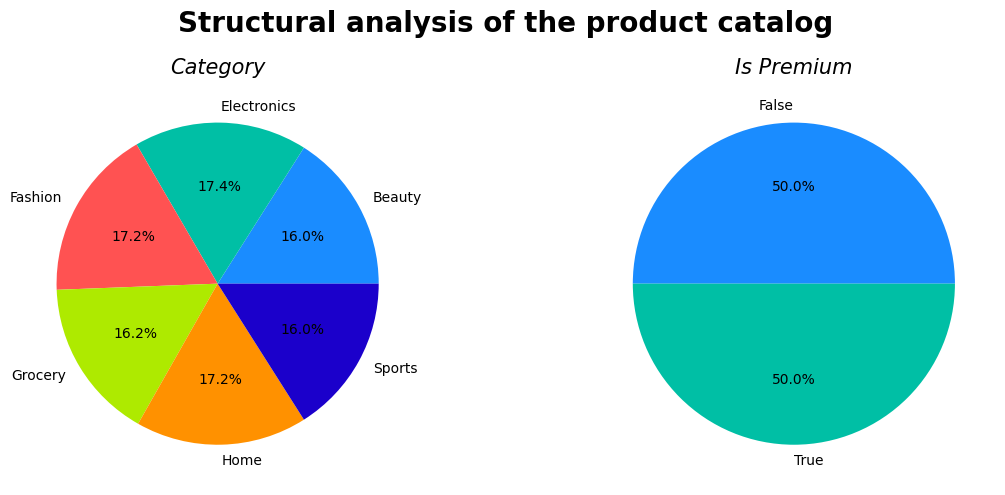

In [22]:
fig, axes=plt.subplots(1, 2, figsize=(12, 5))
df3_pie1=df3.groupby('category', as_index=False)['brand'].nunique()
axes[0].pie(df3_pie1['brand'], labels=df3_pie1['category'], colors=my_colors_pack, autopct='%1.1f%%')
axes[0].set_title('Category', fontsize=15, style='italic')
df3_pie2=df3.groupby('is_premium', as_index=False)['product_id'].count()
axes[1].pie(df3_pie2['product_id'], labels=df3_pie2['is_premium'], colors=my_colors_pack, autopct='%1.1f%%')
axes[1].set_title('Is Premium', fontsize=15, style='italic')
plt.suptitle('Structural analysis of the product catalog', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

Inspecting data types, missing values, total dataset size, and the first rows of the transactions table.

Вывод технической сводки по таблице транзакций, выявление пропущенных значений, определение объема выборки и просмотр первых записей.

In [23]:
df4.info(memory_usage='deep')
print(df4.shape)
display(df4.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103127 entries, 0 to 103126
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    103127 non-null  int64  
 1   timestamp         103127 non-null  object 
 2   customer_id       103127 non-null  int64  
 3   product_id        92678 non-null   float64
 4   quantity          103127 non-null  int64  
 5   discount_applied  103127 non-null  float64
 6   gross_revenue     92678 non-null   float64
 7   campaign_id       103127 non-null  int64  
 8   refund_flag       103127 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 13.0 MB
(103127, 9)


,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
0,1,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0
1,2,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0
2,3,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0
3,4,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0
4,5,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0
5,6,2023-01-19 14:05:58,10749,1635.0,2,0.00,169.74,13,0
6,7,2023-07-28 09:37:53,25984,244.0,2,0.00,42.48,21,0
7,8,2022-07-10 07:29:15,85140,1296.0,1,0.00,36.95,2,0
8,9,2023-11-02 05:22:44,52930,1512.0,1,0.00,125.59,23,0
9,10,2021-01-25 06:28:42,69172,1433.0,1,0.15,48.72,44,0


Detecting and counting missing values (nulls) specifically in the product ID and gross revenue columns.

Расчет абсолютного количества пропущенных значений (NaN/Null) в столбцах идентификатора продукта и валовой выручки.

In [24]:
print(df4['product_id'].isna().sum())
print(df4['gross_revenue'].isna().sum())
print(df4[['product_id', 'gross_revenue']].isna().sum())

10449
10449
product_id       10449
gross_revenue    10449
dtype: int64


Removing rows with missing data, optimizing memory by casting IDs to smaller integers, converting timestamps to datetime, and changing flags to boolean.

Удаление строк с пропущенными значениями, оптимизация типов данных, переименование столбцов времени и возврата, приведение типов к datetime и boolean.

In [25]:
df4=df4.dropna()
group_columns=['transaction_id', 'customer_id', 'product_id', 'quantity', 'campaign_id']
df4[group_columns]=df4[group_columns].astype('int32')
df4=df4.rename(columns={'timestamp': 'datetime_transaction', 'refund_flag': 'refund'})
df4['datetime_transaction']=pd.to_datetime(df4['datetime_transaction'])
df4['refund']=df4['refund'].astype('bool')

Re-evaluating descriptive statistics and reviewing data types and rows for the cleaned transactions table.

Повторный расчет описательной статистики для выявления аномалий после очистки (наличие отрицательной выручки) и вывод информации о DataFrame.

In [26]:
display(df4.describe())
df4.info(memory_usage='deep')
display(df4.head(20))

,transaction_id,datetime_transaction,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id
count,92678.000000,92678,92678.000000,92678.00000,92678.000000,92678.000000,92678.000000,92678.000000
mean,51588.622748,2022-07-09 06:39:22.551112192,49908.020005,999.63139,1.381644,0.041302,90.355493,19.947194
min,1.000000,2021-01-01 00:12:50,2.000000,1.00000,1.000000,0.000000,-783.040000,0.000000
25%,25764.500000,2021-10-12 14:33:46.249999872,25022.000000,498.00000,1.000000,0.000000,34.240000,4.000000
50%,51601.500000,2022-07-10 08:18:54,49895.500000,1002.00000,1.000000,0.000000,68.000000,18.000000
75%,77413.750000,2023-04-07 04:26:25.750000128,74825.500000,1498.00000,1.000000,0.050000,117.617500,34.000000
max,103127.000000,2023-12-31 22:37:32,100000.000000,2000.00000,4.000000,0.200000,1858.320000,50.000000
std,29792.093643,NaN,28831.422859,576.19187,0.748981,0.060209,100.684683,16.379127


<class 'pandas.core.frame.DataFrame'>
Index: 92678 entries, 0 to 103126
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   transaction_id        92678 non-null  int32         
 1   datetime_transaction  92678 non-null  datetime64[ns]
 2   customer_id           92678 non-null  int32         
 3   product_id            92678 non-null  int32         
 4   quantity              92678 non-null  int32         
 5   discount_applied      92678 non-null  float64       
 6   gross_revenue         92678 non-null  float64       
 7   campaign_id           92678 non-null  int32         
 8   refund                92678 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), int32(5)
memory usage: 4.7 MB


,transaction_id,datetime_transaction,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund
0,1,2021-12-27 08:25:15,59540,1630,3,0.00,43.74,0,False
1,2,2023-06-06 21:14:26,54871,1901,3,0.00,174.78,21,False
2,3,2023-08-31 05:29:54,51818,1884,1,0.00,40.61,37,False
3,4,2022-06-26 20:33:46,18164,1114,2,0.15,68.76,13,False
4,5,2023-07-26 18:12:35,86915,408,1,0.00,14.64,4,False
5,6,2023-01-19 14:05:58,10749,1635,2,0.00,169.74,13,False
6,7,2023-07-28 09:37:53,25984,244,2,0.00,42.48,21,False
7,8,2022-07-10 07:29:15,85140,1296,1,0.00,36.95,2,False
8,9,2023-11-02 05:22:44,52930,1512,1,0.00,125.59,23,False
9,10,2021-01-25 06:28:42,69172,1433,1,0.15,48.72,44,False


Sorting transactions chronologically and extracting time-based features: year, month, day of week, time of day intervals, and separating sales from refunds.

Хронологическая сортировка транзакций, извлечение временных признаков (год, месяц, день недели, интервал суток), а также разделение объемов успешных продаж и возвратов.

In [27]:
group_df4=df4.sort_values(by='datetime_transaction').copy()
group_df4['year']=group_df4['datetime_transaction'].dt.year
group_df4['month']=group_df4['datetime_transaction'].dt.month_name()
group_df4['month_idx']=group_df4['datetime_transaction'].dt.month
group_df4['day_week']=group_df4['datetime_transaction'].dt.day_name()
group_df4['day_idx']=group_df4['datetime_transaction'].dt.dayofweek
conditions=[
    group_df4['datetime_transaction'].dt.hour.between(0, 5),
    group_df4['datetime_transaction'].dt.hour.between(6, 11),
    group_df4['datetime_transaction'].dt.hour.between(12, 17)
    ]
results=['Night', 'Morning', 'Afternoon']
group_df4['interval_day']=np.select(conditions, results, default='Evening')
group_df4['interval_idx']=np.select(conditions, [1, 2, 3], default=4)
group_df4['sell_count']=np.where(group_df4['refund']==False, group_df4['quantity'], 0)
group_df4['refund_count']=np.where(group_df4['refund']==True, group_df4['quantity'], 0)
display(group_df4.head(20))

,transaction_id,datetime_transaction,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund,year,month,month_idx,day_week,day_idx,interval_day,interval_idx,sell_count,refund_count
15114,15115,2021-01-01 00:12:50,71651,475,2,0.10,333.92,23,False,2021,January,1,Friday,4,Night,1,2,0
47644,47645,2021-01-01 00:25:45,31554,1036,1,0.15,53.99,0,False,2021,January,1,Friday,4,Night,1,1,0
7781,7782,2021-01-01 00:32:50,44586,353,2,0.00,142.02,0,False,2021,January,1,Friday,4,Night,1,2,0
45951,45952,2021-01-01 02:09:11,48765,1823,1,0.15,14.89,16,False,2021,January,1,Friday,4,Night,1,1,0
94254,94255,2021-01-01 02:37:31,30382,1711,1,0.00,81.58,2,False,2021,January,1,Friday,4,Night,1,1,0
63611,63612,2021-01-01 03:12:46,32000,367,1,0.00,115.66,5,False,2021,January,1,Friday,4,Night,1,1,0
88301,88302,2021-01-01 04:07:27,52548,1778,1,0.00,120.97,36,False,2021,January,1,Friday,4,Night,1,1,0
34898,34899,2021-01-01 05:05:58,45350,346,1,0.05,52.48,43,False,2021,January,1,Friday,4,Night,1,1,0
7759,7760,2021-01-01 05:27:50,10687,1011,1,0.00,69.30,15,False,2021,January,1,Friday,4,Night,1,1,0
78152,78153,2021-01-01 05:28:37,2715,1372,1,0.05,36.77,0,False,2021,January,1,Friday,4,Night,1,1,0


Aggregating transactional KPIs (unique users, products, total revenue, sales, and refunds) across different time dimensions: years, months, days, and hours.

Расчет агрегированных бизнес-показателей (выручка, объемы продаж и возвратов, уникальные клиенты/товары) в разрезе лет, месяцев, дней недели и интервалов суток.

In [28]:
group_columns1=['customer_id', 'product_id', 'quantity', 'gross_revenue', 'sell_count', 'refund_count']
aggregate1={'customer_id': 'nunique',
            'product_id': 'nunique',
            'gross_revenue': 'sum',
            'sell_count': 'sum',
            'refund_count': 'sum'}
df4_year_result=group_df4.groupby('year', as_index=False)[group_columns1].agg(aggregate1)
df4_month_result=group_df4.groupby(['month', 'month_idx'], as_index=False)[group_columns1].agg(
    aggregate1).sort_values(by='month_idx').drop(columns=['month_idx'])
df4_day_result=group_df4.groupby(['day_week', 'day_idx'], as_index=False)[group_columns1].agg(
    aggregate1).sort_values(by='day_idx').drop(columns=['day_idx'])
df4_interval_result=group_df4.groupby(['interval_day', 'interval_idx'], as_index=False)[group_columns1].agg(
    aggregate1).sort_values(by='interval_idx').drop(columns=['interval_idx'])
for i in [df4_year_result, df4_month_result, df4_day_result, df4_interval_result]:
    i.index=np.arange(1, len(i)+1)
display(df4_year_result)
display(df4_month_result)
display(df4_day_result)
display(df4_interval_result)

,year,customer_id,product_id,gross_revenue,sell_count,refund_count
1,2021,26650,2000,2817199.32,41707,1181
2,2022,26296,2000,2785927.47,41344,1346
3,2023,26495,2000,2770839.57,41237,1233


,month,customer_id,product_id,gross_revenue,sell_count,refund_count
1,January,7298,1962,685535.45,10162,310
2,February,6442,1922,623265.17,9069,256
3,March,7183,1964,656470.28,9898,323
4,April,6963,1941,654574.79,9705,326
5,May,7208,1945,696039.88,10174,289
6,June,6994,1949,654272.89,9715,267
7,July,7160,1964,671064.19,9989,322
8,August,7293,1947,684339.75,10120,330
9,September,7041,1944,640083.02,9642,299
10,October,7207,1948,682138.17,10104,284


,day_week,customer_id,product_id,gross_revenue,sell_count,refund_count
1,Monday,11965,2000,1160830.64,17164,539
2,Tuesday,12117,1995,1165202.67,17152,539
3,Wednesday,12116,1996,1166295.03,17238,527
4,Thursday,11966,1999,1134643.69,17062,556
5,Friday,12134,1997,1170914.68,17394,481
6,Saturday,13232,1994,1283915.51,19057,557
7,Sunday,13277,1999,1292164.14,19221,561


,interval_day,customer_id,product_id,gross_revenue,sell_count,refund_count
1,Night,13305,1998,1282506.22,19089,603
2,Morning,21586,2000,2224101.47,32662,910
3,Afternoon,24179,2000,2476006.54,37061,1179
4,Evening,23091,2000,2391352.13,35476,1068


Plotting three line charts to analyze the monthly trends of successful sales, product returns, and total gross revenue over time.

Визуализация временных рядов: построение линейных графиков ежемесячной динамики успешных продаж, возвратов и валовой выручки.

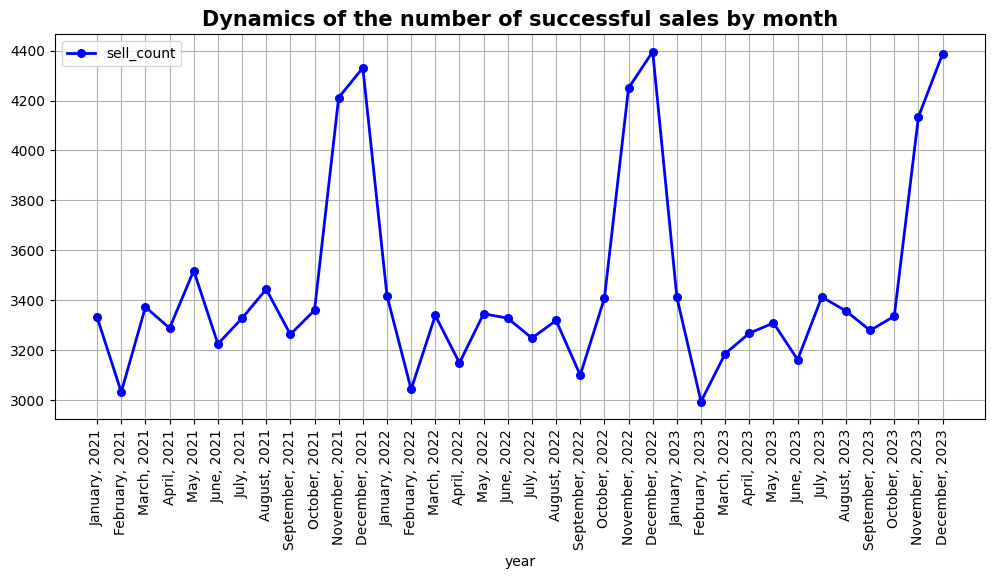

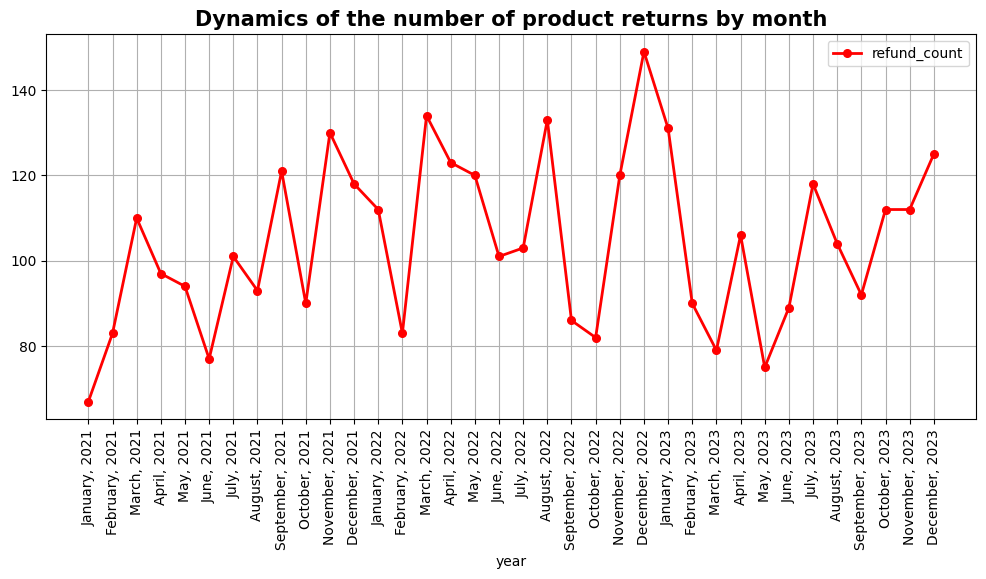

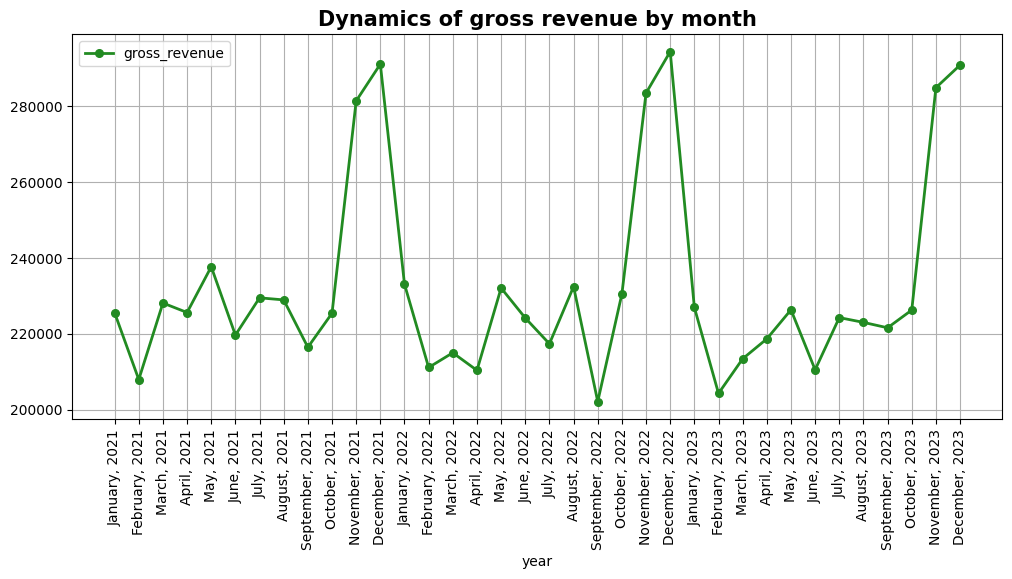

In [29]:
line1=group_df4.groupby(['year', 'month', 'month_idx'], as_index=False)[['sell_count', 'refund_count', 'gross_revenue']].sum()
line1=line1.sort_values(by=['year', 'month_idx'])
line1['year']=line1['month'].str.cat(line1['year'].astype('str'), sep=', ')
line1=line1.drop(['month_idx', 'month'], axis=1)
line1_graphic_parameters=[
    ('sell_count', 'blue', 'the number of successful sales'),
    ('refund_count', 'red', 'the number of product returns'),
    ('gross_revenue', 'forestgreen', 'gross revenue')]
for row, graphic_color, fragment in line1_graphic_parameters:
    line1.plot(kind='line', x='year', y=row, figsize=(12, 5), color=graphic_color, linewidth=2, marker='o', markersize=5.5)
    plt.title(f'Dynamics of {fragment} by month', fontsize=15, fontweight='bold')
    plt.grid()
    plt.xticks(range(len(line1)), line1['year'], rotation=90)
    plt.show()

Merging transactions with campaign, customer, and product tables to calculate total revenue, sales, and refunds across various strategic dimensions.

Слияние таблиц транзакций, кампаний, клиентов и продуктов через операцию Join. Проведение многомерного агрегированного анализа финансовых показателей по ключевым бизнес-метрикам.

In [30]:
merge_table1=pd.merge(df1, group_df4, on='campaign_id', how='left')
merge_table2=pd.merge(group_df2, group_df4, on='customer_id', how='left')
merge_table3=pd.merge(df3, group_df4, on='product_id', how='left')
group_columns2=['gross_revenue', 'sell_count', 'refund_count']
dict1=dict.fromkeys(['channel', 'objective'], merge_table1)
dict2=dict.fromkeys(['age_status', 'country', 'loyalty_tier', 'acquisition_channel', 'gender'], merge_table2)
dict3=dict.fromkeys(['is_premium', 'category', 'brand'], merge_table3)
total_dict=dict1|dict2|dict3
analysis_dict={}
def analysis(df, row):
    return df.groupby(row, as_index=False)[group_columns2].sum()
for i, j in total_dict.items():
    analysis_dict[i]=analysis(j, i)
    if (analysis_dict[i][analysis_dict[i].columns[0]].count())>10:
        analysis_dict[i]=analysis_dict[i].sort_values(by=['gross_revenue'], ascending=False).head(10)
    display(analysis_dict[i])
    print('')

,channel,gross_revenue,sell_count,refund_count
0,Affiliate,1608144.17,23863,663
1,Display,1211416.38,17943,544
2,Email,1357550.66,20261,618
3,Paid Search,1533909.64,22669,740
4,Social,972825.47,14316,428


,objective,gross_revenue,sell_count,refund_count
0,Acquisition,1310592.78,19472,574
1,Cross-sell,1602569.22,23606,703
2,Reactivation,1955676.20,29170,892
3,Retention,1815008.12,26804,824


,age_status,gross_revenue,sell_count,refund_count
0,Middle,3815900.11,56772.0,1735.0
1,Older,58839.88,905.0,29.0
2,Young,4156838.99,61610.0,1862.0


,country,gross_revenue,sell_count,refund_count
0,Australia,566026.05,8438.0,285.0
1,Brazil,809508.39,12071.0,359.0
2,Canada,783370.02,11803.0,390.0
3,Germany,626747.43,9403.0,285.0
4,India,1608222.45,23977.0,720.0
5,USA,2833231.56,41722.0,1213.0
6,United Kingdom,804473.08,11873.0,374.0


,loyalty_tier,gross_revenue,sell_count,refund_count
0,Bronze,4292707.40,63997.0,1959.0
1,Gold,1218257.57,18354.0,560.0
2,Platinum,306094.39,4548.0,163.0
3,Silver,2214519.62,32388.0,944.0


,acquisition_channel,gross_revenue,sell_count,refund_count
0,Email,1198061.85,17804.0,494.0
1,Organic,2463283.05,36234.0,1091.0
2,Paid Search,2400243.04,35806.0,1105.0
3,Referral,799351.42,11903.0,327.0
4,Social,1170639.62,17540.0,609.0


,gender,gross_revenue,sell_count,refund_count
0,Female,4022613.19,59617.0,1832.0
1,Male,4008965.79,59670.0,1794.0


,is_premium,gross_revenue,sell_count,refund_count
0,False,1922351.91,62005,1848
1,True,6451614.45,62283,1912


,category,gross_revenue,sell_count,refund_count
0,Beauty,369671.88,12302,384
1,Electronics,3452007.19,28347,847
2,Fashion,1298075.77,26058,767
3,Grocery,292169.45,19335,595
4,Home,1996432.94,24549,689
5,Sports,965609.13,13697,478


,brand,gross_revenue,sell_count,refund_count
68,Brand_70,146317.73,1435,53
70,Brand_72,131260.39,1909,58
67,Brand_7,130946.29,2029,89
84,Brand_85,126313.05,1606,56
17,Brand_24,122461.33,1448,27
57,Brand_60,115919.22,1549,51
56,Brand_6,115559.87,1278,32
83,Brand_84,115235.97,1653,56
12,Brand_2,113339.24,1406,47
48,Brand_52,110304.53,1705,69


Defining a reusable plotting function to create side-by-side bar charts for revenue, sales, and refunds for any given aggregated dataset.

Разработка универсальной функции визуализации для автоматического построения парных диаграмм (выручка / продажи и возвраты) для любого переданного датасета.

In [31]:
def make_graphics(df, main_title):
    fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(12, 5))
    fontsize_value=10 if df[df.columns[0]].count()<10 else 8
    rotation_value=0 if df[df.columns[0]].count()<10 else 90
    df.plot(kind='bar', x=df.columns[0], y='gross_revenue', color='blue', width=0.7, ax=ax1)
    for i in ax1.containers:
        ax1.bar_label(i, padding=2, fmt='%.0f', fontsize=fontsize_value)
    ax1.set_xlabel('')
    ax1.set_title('Gross Revenue', style='italic')
    ax1.set_ylim(1, df['gross_revenue'].max()*1.1)
    ax1.tick_params(axis='x', rotation=rotation_value)
    ax1.legend(loc='lower left')
    df.plot(kind='bar', x=df.columns[0], y=['refund_count', 'sell_count'], width=0.9, color=['red', 'forestgreen'], ax=ax2)
    for i in ax2.containers:
        ax2.bar_label(i, padding=2, fontsize=8)
    ax2.set_yscale('log')
    ax2.set_xlabel('')
    ax2.set_title('Sell & Refund', style='italic')
    ax2.set_ylim(1, df['sell_count'].max()*1.8)
    ax2.tick_params(axis='x', rotation=rotation_value)
    ax2.legend(loc='lower left')
    plt.suptitle(main_title, fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('')

Running the custom visualization function across all pre-calculated analytical tables to create a complete visual report.

Последовательный вызов разработанной функции визуализации для всех ранее рассчитанных срезов данных с целью формирования графического отчета.

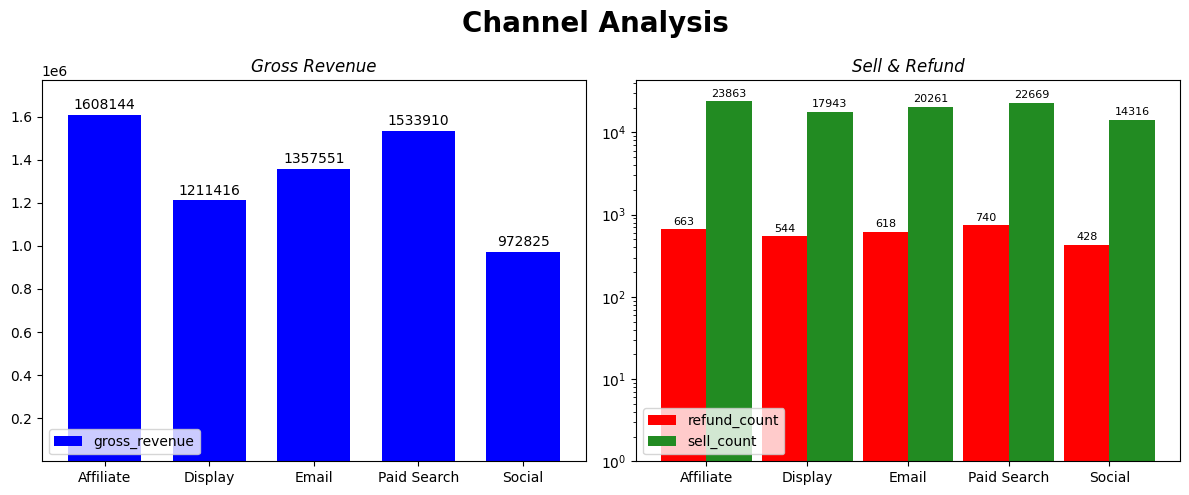

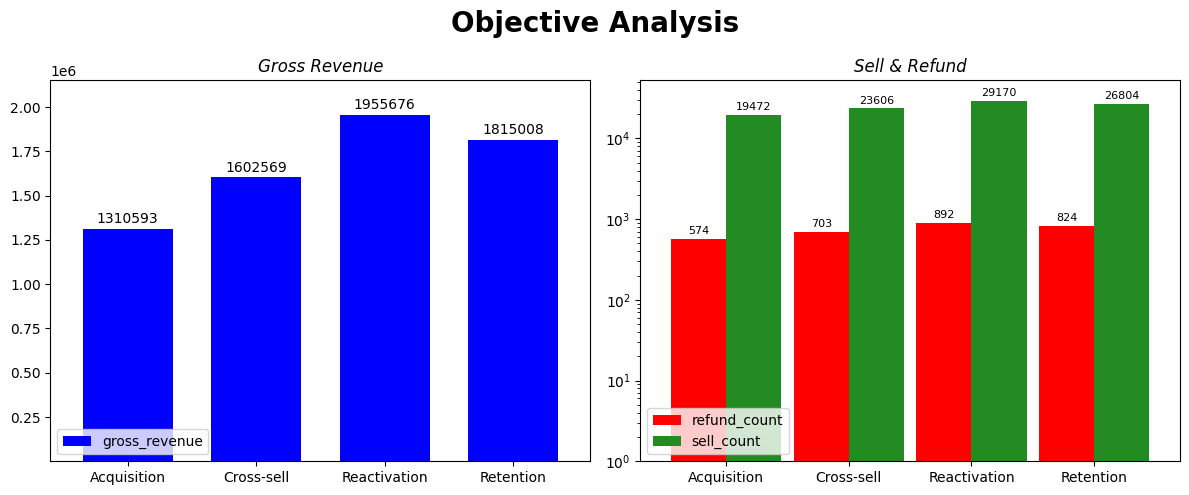

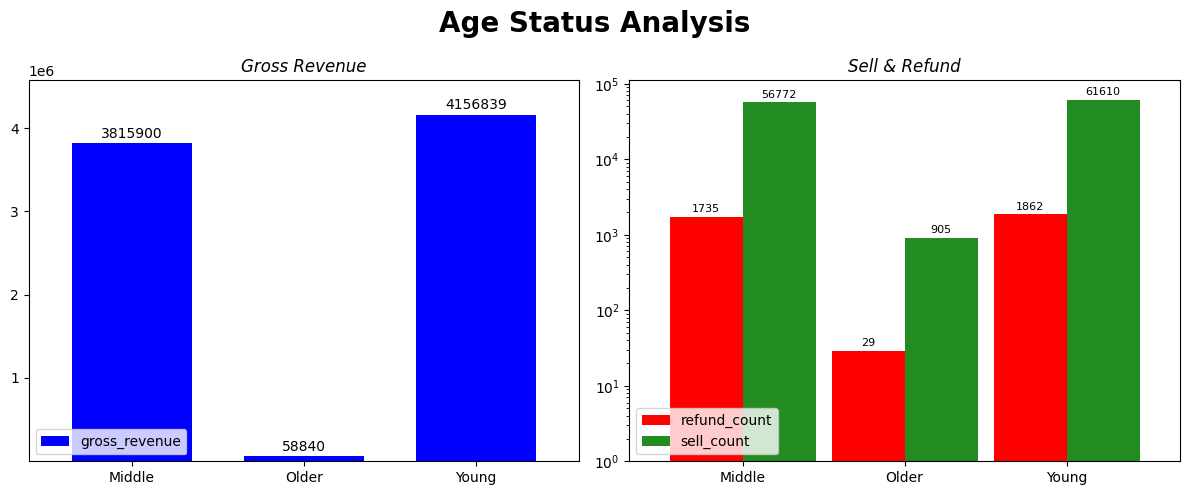

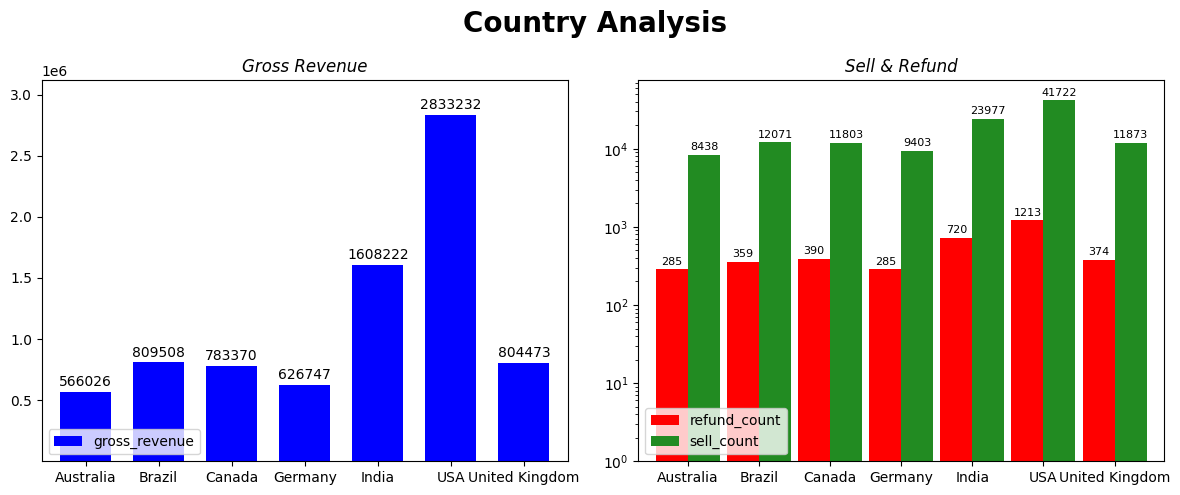

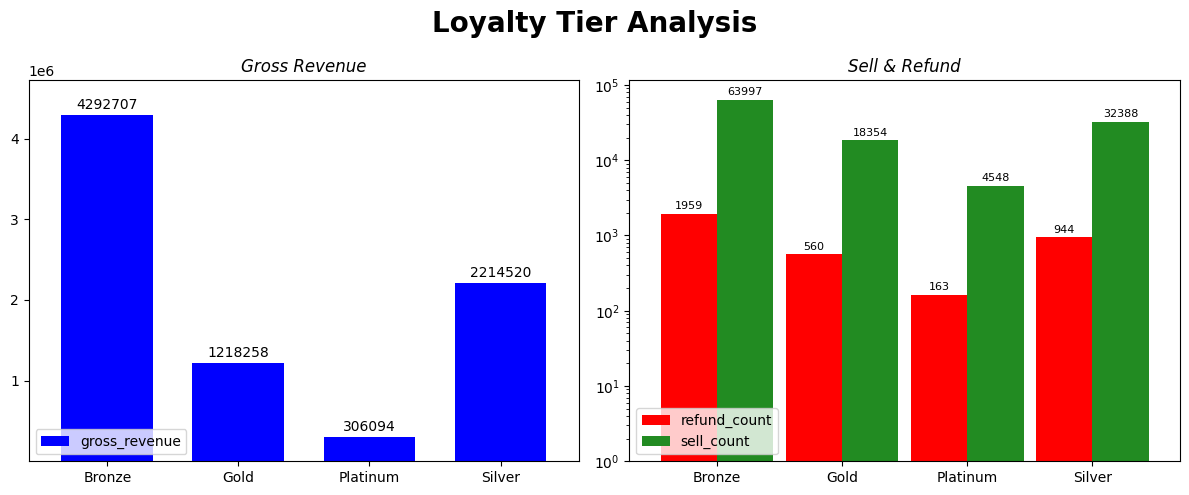

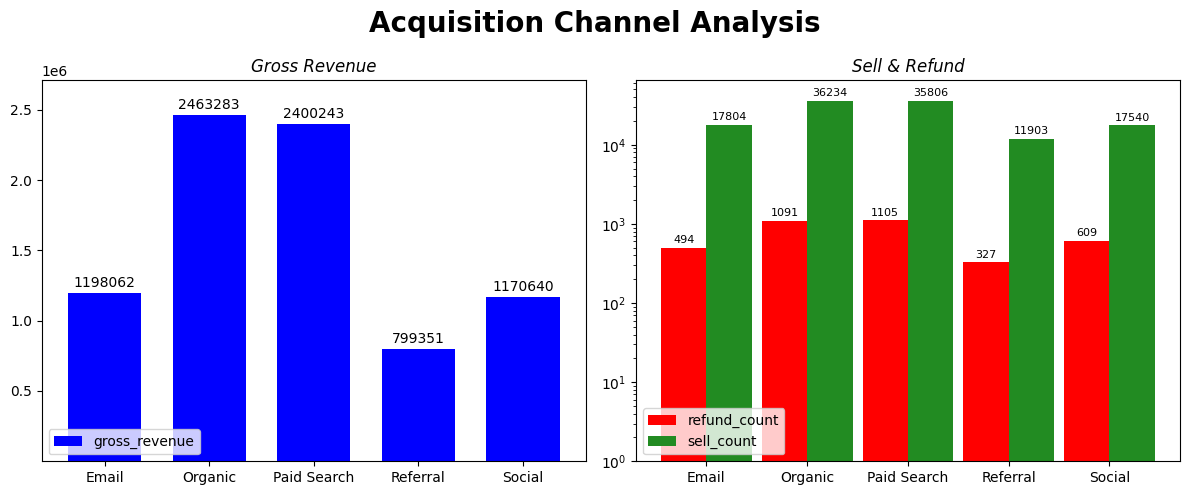

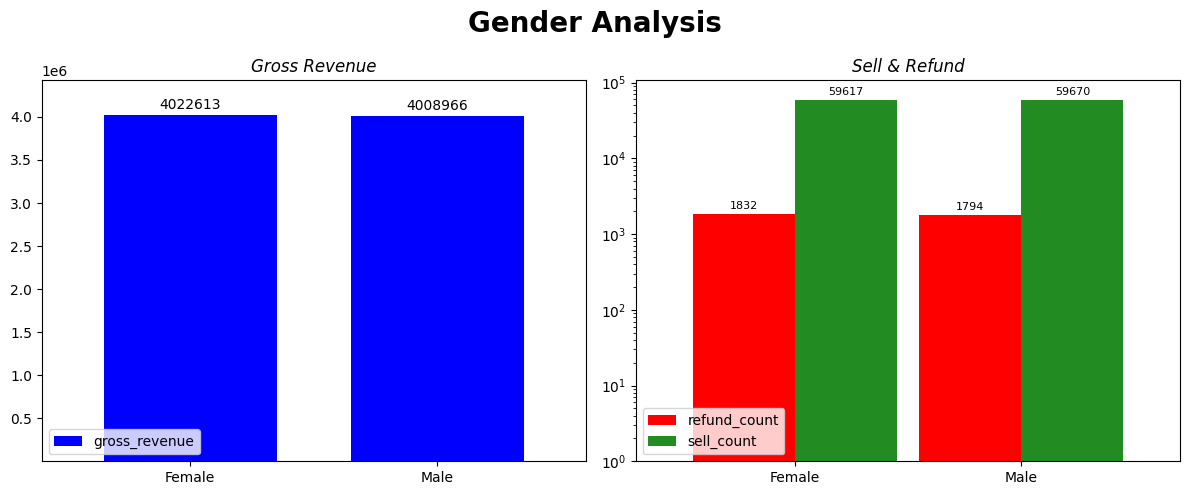

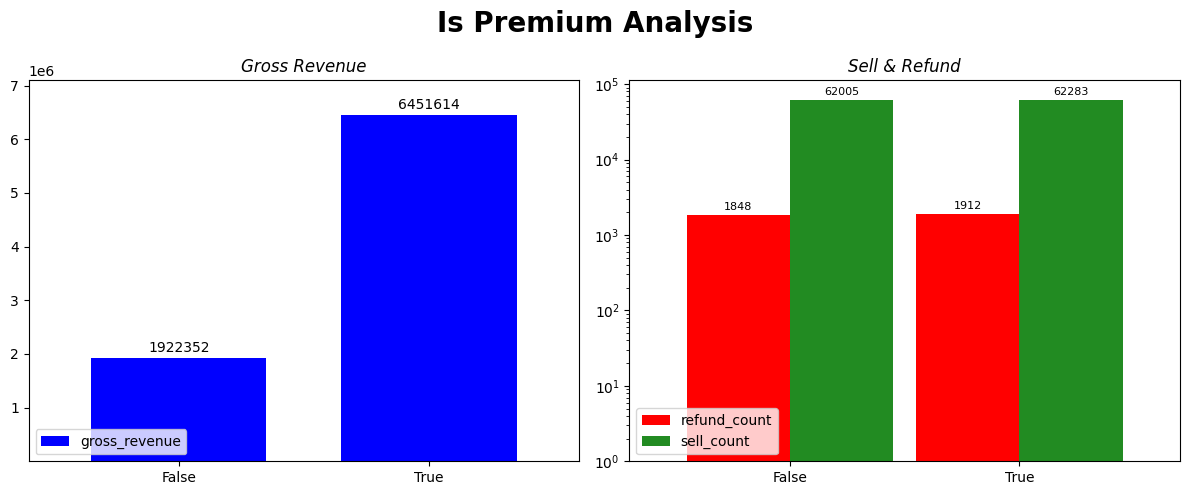

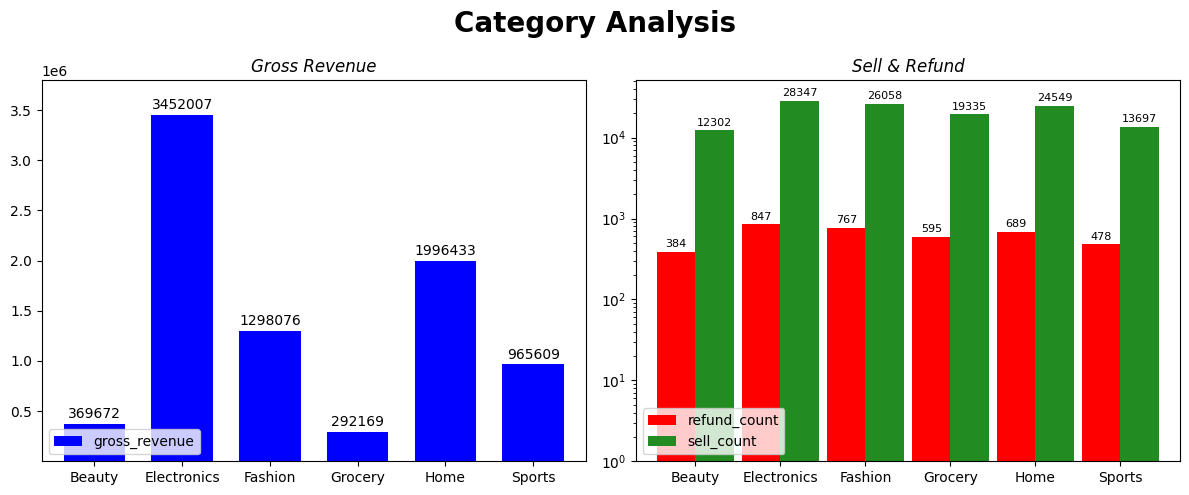

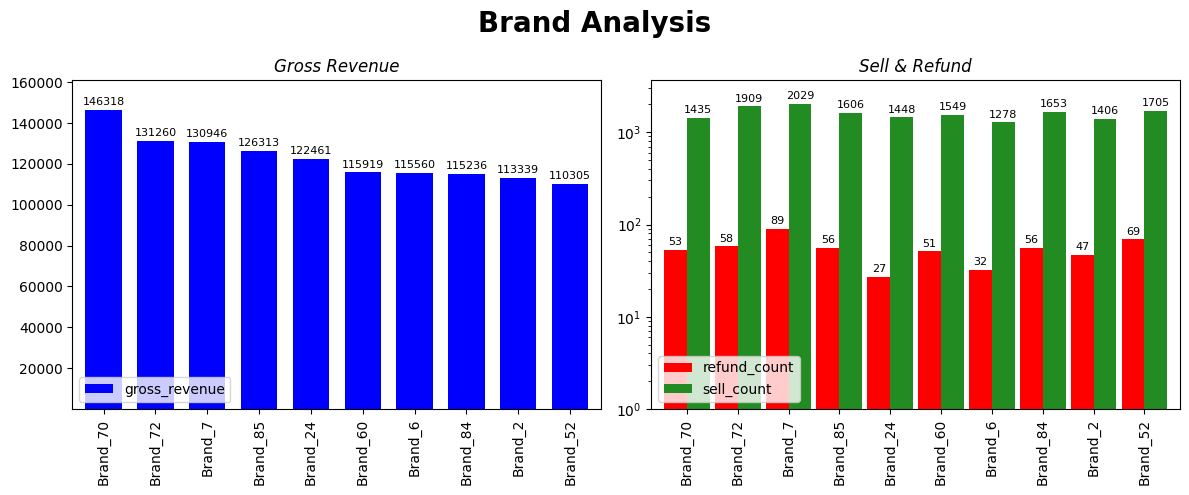

In [32]:
graphic_dict={i: i.replace('_', ' ').title()+' Analysis' for i in analysis_dict.keys()}
for row, graphic_title in graphic_dict.items():
    make_graphics(analysis_dict[row], graphic_title)

Uploading the finalized, cleaned datasets (campaigns, customers, products, transactions) back into the SQL database tables.

Экспорт очищенных и структурированных таблиц (маркетинговые кампании, профили клиентов, каталог продуктов, транзакции) в соответствующие таблицы базы данных.

In [33]:
df1.to_sql(name='campaigns', con=engine, if_exists="append", index=False)
df2.to_sql(name='customers', con=engine, if_exists="append", index=False)
df3.to_sql(name='products', con=engine, if_exists="append", index=False)
df4.to_sql(name='transactions', con=engine, if_exists="append", index=False)

Exporting the final cleaned DataFrames (movies, shows, actors, directors) into separate CSV files.

Экспорт окончательно очищенных фрагментов данных (фильмы, шоу, актеры, режиссеры) в отдельные CSV-файлы.

In [34]:
df1.to_csv('ecommerce_campaigns.csv', index=False)
df2.to_csv('ecommerce_customers.csv', index=False)
df3.to_csv('ecommerce_products.csv', index=False)
df4.to_csv('ecommerce_transactions.csv', index=False)